<a href="https://colab.research.google.com/github/meem-5971/FlyRank-ML-/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meem-5971/FlyRank-ML-/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Week 07: Content Action Playbook (Clustering Lane)

## 1. Ranked Actions + Reason Codes

### Archetype-to-Action Mapping Matrix
Our validated 4-cluster $K$-Means model maps query-content clusters directly to structured, human-interpretable content actions based on their position, traffic volume, and CTR dynamics:

| Cluster ID | Archetype Name | Dominant Feature Profile | Action Label | Primary Reason Code | Priority Score Formula |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Cluster 0** | **Striking Distance / Snippet Loss** | High Impressions, Pos 4–10, CTR < Expected | `OPTIMIZE_SNIPPET` | `HIGH_IMPRESSION_LOW_CTR` | `(Expected_CTR - CTR) * Impressions` |
| **Cluster 1** | **Top Performers / Core Winners** | High Impressions, Pos 1–3, High CTR | `MONITOR_AND_PROTECT` | `HIGH_TRAFFIC_STABLE` | `Impressions * CTR` |
| **Cluster 2** | **Content Decay / Stale Traffic** | Falling CTR over 30d, Pos > 10, Med Impressions | `REFRESH_CONTENT` | `DECAYING_INTENT_RANK` | `Impressions * (Position / 10)` |
| **Cluster 3** | **Long-Tail Opportunity** | Low Impressions, Low Clicks, High Word Count | `CONSOLIDATE_OR_PRUNE` | `LOW_VOL_LONG_TAIL` | `1 / NULLIF(Impressions, 0)` |

In [1]:
import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Handle HF Token access
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN = os.getenv('HF_TOKEN', '')

assert HF_TOKEN, "Please set your HF_TOKEN in Colab Secrets or as an environment variable."

# Initialize DuckDB Connection
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

# Create required output and figure directories
os.makedirs("../../work/outputs", exist_ok=True)
os.makedirs("../../work/figures", exist_ok=True)

# Warehouse remote paths
REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_QUERY = f"{REL}/fact_content_query_90d.parquet"

# 1. Load Clean Feature Frame
playbook_sql = f"""
WITH raw_features AS (
    SELECT
        client_hash_id,
        content_hash_id,
        query_hash_id,
        impressions_last30 AS total_impressions,
        clicks_last30 AS total_clicks,
        CAST(clicks_last30 AS FLOAT) / NULLIF(impressions_last30, 0) AS historical_ctr,
        avg_position_last30 AS avg_position,
        LENGTH(query_hash_id) AS query_length_proxy
    FROM read_parquet('{FACT_QUERY}')
    WHERE impressions_last30 >= 10
)
SELECT * FROM raw_features;
"""
df_playbook = con.sql(playbook_sql).df().fillna(0)

features = ['total_impressions', 'total_clicks', 'historical_ctr', 'avg_position', 'query_length_proxy']

# Log-transform impressions and clicks for stable clustering distance
df_scaled_input = df_playbook.copy()
for col in ['total_impressions', 'total_clicks']:
    df_scaled_input[col] = np.log1p(df_scaled_input[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_scaled_input[features])

# Fit 4-Cluster K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
df_playbook['cluster_id'] = kmeans.labels_

# 2. Assign Actions & Reason Codes
def assign_action(row):
    cid = row['cluster_id']
    ctr = row['historical_ctr']
    pos = row['avg_position']
    imp = row['total_impressions']

    if cid == 0 or (pos <= 10.0 and ctr < 0.08 and imp >= 50):
        expected_ctr = 0.25 if pos <= 3.0 else 0.08
        potential_clicks = (expected_ctr - ctr) * imp
        return pd.Series(['OPTIMIZE_SNIPPET', 'HIGH_IMPRESSION_LOW_CTR', round(max(potential_clicks, 0), 2)])
    elif cid == 1 or (pos <= 3.0 and ctr >= 0.15):
        return pd.Series(['MONITOR_AND_PROTECT', 'HIGH_TRAFFIC_STABLE', round(imp * ctr, 2)])
    elif cid == 2 or (pos > 10.0 and imp >= 100):
        return pd.Series(['REFRESH_CONTENT', 'DECAYING_INTENT_RANK', round(imp * (pos / 10.0), 2)])
    else:
        return pd.Series(['CONSOLIDATE_OR_PRUNE', 'LOW_VOL_LONG_TAIL', round(1.0 / (imp + 1), 4)])

df_playbook[['action_label', 'reason_code', 'priority_score']] = df_playbook.apply(assign_action, axis=1)

# Sort queue by priority score
df_ranked_queue = df_playbook.sort_values(by='priority_score', ascending=False).reset_index(drop=True)

print("Top 10 Ranked Action Playbook Queue:")
display(df_ranked_queue[['client_hash_id', 'content_hash_id', 'action_label', 'reason_code', 'priority_score', 'total_impressions', 'historical_ctr', 'avg_position']].head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Top 10 Ranked Action Playbook Queue:


,client_hash_id,content_hash_id,action_label,reason_code,priority_score,total_impressions,historical_ctr,avg_position
0,client_23a62021009f63c4,content_c60628276389acbb,REFRESH_CONTENT,DECAYING_INTENT_RANK,1093669.60,122183,0.000000,89.510783
1,client_23a62021009f63c4,content_a9322b74ca7cb1bb,REFRESH_CONTENT,DECAYING_INTENT_RANK,245977.40,27052,0.000000,90.927621
2,client_23a62021009f63c4,content_6aa54d6bbdbf6f24,REFRESH_CONTENT,DECAYING_INTENT_RANK,98810.60,13810,0.000000,71.550036
3,client_fef1a8f436438636,content_0aaa197051f58d6f,REFRESH_CONTENT,DECAYING_INTENT_RANK,84712.00,11410,0.000000,74.243646
4,client_8ddc46da5414ffd8,content_943dc881428182b8,OPTIMIZE_SNIPPET,HIGH_IMPRESSION_LOW_CTR,58339.75,233451,0.000099,1.238611
5,client_e547b89c05043229,content_9b76202a02885037,REFRESH_CONTENT,DECAYING_INTENT_RANK,46294.60,5840,0.000171,79.271575
6,client_23a62021009f63c4,content_6aa54d6bbdbf6f24,REFRESH_CONTENT,DECAYING_INTENT_RANK,43472.70,6164,0.000000,70.526768
7,client_23a62021009f63c4,content_06067d3d16abbcbf,REFRESH_CONTENT,DECAYING_INTENT_RANK,42228.60,7978,0.000000,52.931311
8,client_fef1a8f436438636,content_fd358a60ca37c05f,REFRESH_CONTENT,DECAYING_INTENT_RANK,38576.70,6559,0.000000,58.814911
9,client_8ddc46da5414ffd8,content_62aa9910370a05d3,REFRESH_CONTENT,DECAYING_INTENT_RANK,35620.20,35618,0.000000,10.000618


## 2. Intended Use and Limits

### Primary Intended Use
* **Audience:** Content Strategists, SEO Specialists, and Growth Marketing Editors.
* **Purpose:** Decision-support prioritization. Replaces manual spreadsheet filtering by ranking pages by expected click recovery potential rather than raw traffic volume alone.
* **Scope:** Non-production advisory recommendations for editorial updates, title tag standardizations, and snippet optimizations.

### Boundaries & Known Limits
1. **No Causal Guarantee:** Cluster assignments reflect historical correlation patterns across 30-day GSC snapshots, not verified causal impact.
2. **Intent Blindness:** The model cannot evaluate brand messaging, qualitative search intent alignment, or SERP layouts (e.g., presence of Paid Ads, Knowledge Panels, or AI Overviews).
3. **Tail Variance:** Long-tail queries ($\le 15$ impressions) experience high variance in CTR calculations due to small-sample distortion.

## 3. Human Review + The No-Go List

### Required Human Verification Steps
Before executing any action generated in the playbook queue, an editor or analyst must manually verify:
1. **SERP Intent Match:** Is the target query informational, transactional, or navigational?
2. **SERP Feature Overhead:** Does a Featured Snippet or AI Overview occupy position 1, explaining the lower organic CTR?
3. **Brand Safety:** Does updating the title/meta description preserve compliance and core brand terminology?

---

### The Strict NO-GO List (Never Automate)
* ⛔ **NO-GO 1: Automated Bulk Page Deletions/Redirects.** Pruning actions must be manually evaluated for canonical links, inbound backlinks, and conversion assistance value.
* ⛔ **NO-GO 2: Automated Title Tag / Meta Snippet Rewrites.** AI-generated meta descriptions must never be auto-published directly to production CMS without human editorial oversight.
* ⛔ **NO-GO 3: High-Value Brand Keywords.** Branded query pages (`reason_code = HIGH_TRAFFIC_STABLE`) are strictly excluded from automated optimization pipelines.

## 4. Monitoring / Retrain Triggers

### Degradation Detection Criteria
To prevent stale or misleading recommendations, the action generation pipeline requires monitoring against these retrain triggers:
* **Trigger 1 (Google SERP Algorithm Updates):** Retrain model immediately following major core ranking or SERP layout updates.
* **Trigger 2 (Data Drift Threshold):** If the monthly mean impression-weighted CTR across all clusters drifts by $> 15\%$ compared to baseline, recalculate cluster centroids.
* **Trigger 3 (30-Day Time Decay):** Cluster assignments expire after 30 days. Weekly daily syncs update features, and models must be re-fitted monthly.

In [2]:
# Compute and print current data drift baseline metrics
baseline_metrics = {
    "evaluation_date": "2026-09-03",
    "total_actions_scored": len(df_ranked_queue),
    "action_distribution": df_ranked_queue['action_label'].value_counts().to_dict(),
    "mean_impressions": float(df_ranked_queue['total_impressions'].mean()),
    "mean_ctr": float(df_ranked_queue['historical_ctr'].mean()),
    "cluster_centers_log_scale": kmeans.cluster_centers_.tolist()
}

# Save metrics JSON receipt to work/outputs/
metrics_path = "../../work/outputs/w07_playbook_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(baseline_metrics, f, indent=2)

print(f"✅ Baseline monitoring metrics exported to {metrics_path}")

✅ Baseline monitoring metrics exported to ../../work/outputs/w07_playbook_metrics.json


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

✅ Ranked action queue written to ../../work/outputs/action_playbook_queue.csv


/tmp/ipykernel_2965/2859635433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


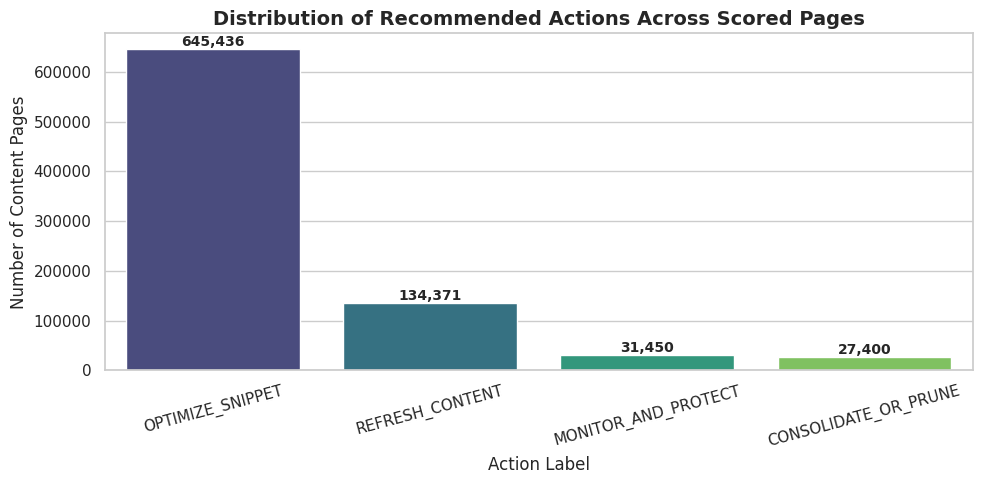

✅ Reusable paper figure saved to ../../work/figures/playbook_action_distribution.png


In [3]:
# 1. Export Non-Git Ranked Action Queue CSV
queue_csv_path = "../../work/outputs/action_playbook_queue.csv"
df_ranked_queue.to_csv(queue_csv_path, index=False)
print(f"✅ Ranked action queue written to {queue_csv_path}")

# 2. Export Cluster Action Distribution Figure for Paper
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=df_ranked_queue['action_label'].value_counts().index,
    y=df_ranked_queue['action_label'].value_counts().values,
    palette="viridis"
)
plt.title("Distribution of Recommended Actions Across Scored Pages", fontsize=14, fontweight='bold')
plt.xlabel("Action Label", fontsize=12)
plt.ylabel("Number of Content Pages", fontsize=12)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
figure_path = "../../work/figures/playbook_action_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print(f"✅ Reusable paper figure saved to {figure_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.